# EDA — Exploration du churn (LECTURE SEULE sur Silver)

Notebook Jupyter réservé à l'exploration. Aucune écriture S3 ici.
L'ETL est dans `src/engineering/` (VS Code), pas dans les notebooks.

In [11]:
%pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.0 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 95.1 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/5.0 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 34.4 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [matplotlib]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [matplotlib]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [matplotlib]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


Note: you may need to restart the kernel to use updated packages.


In [23]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src import config
from pyspark.sql import functions as F

spark = config.build_spark(app_name='eda-churn')
spark.sparkContext.setLogLevel('WARN')
print('Bucket :', config.S3_BUCKET)
print('Silver :', config.s3_path('silver'))

Bucket : nacerdinedouniaamira
Silver : s3a://nacerdinedouniaamira/silver/churn_clean


## 1. Chargement de Silver

In [24]:
df = spark.read.parquet(config.s3_path('silver'))
df.cache()
n_rows = df.count()
print(f'Lignes   : {n_rows:,}')
print(f'Colonnes : {len(df.columns)}')
df.printSchema()

13:44:24.404 [Thread-3] WARN  org.apache.spark.sql.execution.CacheManager - Asked to cache already cached data.
Lignes   : 704,300
Colonnes : 21
root
 |-- customer_id: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- senior_citizen: double (nullable = true)
 |-- partner: string (nullable = true)
 |-- dependents: string (nullable = true)
 |-- tenure: double (nullable = true)
 |-- phone_service: string (nullable = true)
 |-- multiple_lines: string (nullable = true)
 |-- internet_service: string (nullable = true)
 |-- online_security: string (nullable = true)
 |-- online_backup: string (nullable = true)
 |-- device_protection: string (nullable = true)
 |-- tech_support: string (nullable = true)
 |-- streaming_tv: string (nullable = true)
 |-- streaming_movies: string (nullable = true)
 |-- contract: string (nullable = true)
 |-- paperless_billing: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- monthly_charges: double (nullable = true)
 |-- t

In [25]:
df.show(5, truncate=False)


+--------------+------+--------------+-------+----------+------------------+-------------+--------------+----------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+-----------------+-------------------------+------------------+-------------+-----+
|customer_id   |gender|senior_citizen|partner|dependents|tenure            |phone_service|multiple_lines|internet_service|online_security    |online_backup      |device_protection  |tech_support       |streaming_tv       |streaming_movies   |contract      |paperless_billing|payment_method           |monthly_charges   |total_charges|churn|
+--------------+------+--------------+-------+----------+------------------+-------------+--------------+----------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+-----------------+-------------------------+-----------------

## 2. Intégrité des données — amplification & risque de fuite

Le Bronze a été amplifié ×100. On vérifie **comment** les clients sont dupliqués : ce point
décide de toute la stratégie de split à la modélisation (anti-leakage).

In [26]:
n_cust = df.select('customer_id').distinct().count()
print(f'Lignes totales        : {n_rows:,}')
print(f'customer_id distincts : {n_cust:,}')
print(f'Ratio                 : {n_rows / n_cust:.1f}')
df.select('customer_id').show(5, truncate=False)

Lignes totales        : 704,300
customer_id distincts : 704,300
Ratio                 : 1.0
+--------------+
|customer_id   |
+--------------+
|8168-UQWWF-r35|
|1918-ZBFQJ-r35|
|5176-LMJXE-r35|
|4431-EDMIQ-r35|
|0970-ETWGE-r35|
+--------------+
only showing top 5 rows


**Découverte.** `customer_id` est unique (ratio 1.0) → un contrôle de doublons classique ne
détecte rien. **Mais** le suffixe `-rNN` (ex. `8168-UQWWF-r35`) trahit des **répliques** d'un
même client d'origine. On extrait l'identifiant de base pour vérifier.

In [27]:
tmp = (df
    .withColumn('suffixe', F.regexp_extract('customer_id', r'(-r\d+)$', 1))
    .withColumn('base_id', F.regexp_replace('customer_id', r'-r\d+$', '')))

print("Suffixes distincts :", tmp.select('suffixe').distinct().count())
print("Clients d'origine  :", tmp.select('base_id').distinct().count())

# La cible est-elle constante au sein d'un client d'origine ?
(tmp.groupBy('base_id')
    .agg(F.countDistinct('churn').alias('nb_churn_distinct'))
    .groupBy('nb_churn_distinct').count().show())

Suffixes distincts : 100


Clients d'origine  : 7043


+-----------------+-----+
|nb_churn_distinct|count|
+-----------------+-----+
|                1| 7043|
+-----------------+-----+



### Conclusion §2 — Structure & anti-leakage

- **7 043 clients réels**, chacun répliqué **100 fois** (suffixe `-r00..-r99`, numériques bruités).
  → 704 300 lignes mais seulement 7 043 individus.
- `churn` est **constant** par client d'origine (`nb_churn_distinct = 1` pour les 7 043).

**Décision (modélisation)** : le split train/test se fera **par `base_id`**, jamais par
`randomSplit` aléatoire — sinon des quasi-copies du même client tombent dans train ET test →
AUC artificiellement gonflé. `base_id` devra être propagé jusqu'au Gold.

## 3. Valeurs manquantes

In [29]:
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show(vertical=True)

-RECORD 0----------------
 customer_id       | 0   
 gender            | 0   
 senior_citizen    | 0   
 partner           | 0   
 dependents        | 0   
 tenure            | 0   
 phone_service     | 0   
 multiple_lines    | 0   
 internet_service  | 0   
 online_security   | 0   
 online_backup     | 0   
 device_protection | 0   
 tech_support      | 0   
 streaming_tv      | 0   
 streaming_movies  | 0   
 contract          | 0   
 paperless_billing | 0   
 payment_method    | 0   
 monthly_charges   | 0   
 total_charges     | 0   
 churn             | 0   



**0 valeur manquante sur toutes les colonnes** → le nettoyage Silver (cast `total_charges`,
imputation, dédup) est validé. Aucune imputation supplémentaire nécessaire.

## 4. La cible — taux de churn & déséquilibre

In [32]:
(df.groupBy('churn').agg(F.count('*').alias('n'))
   .withColumn('pct', F.round(100 * F.col('n') / n_rows, 2))
   .orderBy('churn').show())

+-----+------+-----+
|churn|     n|  pct|
+-----+------+-----+
|    0|517400|73.46|
|    1|186900|26.54|
+-----+------+-----+



**26,5 % de churn** (186 900 / 704 300) → classes déséquilibrées (~1:2,8).

**Décision (métriques)** : l'accuracy est trompeuse (prédire toujours « reste » = 73,5 %).
On évaluera en **AUC-ROC, AUC-PR, précision/rappel, F1**. Baseline à battre = classe majoritaire
(AUC 0,5).

## 5. Variables numériques — distribution & outliers

In [33]:
num_cols = ['tenure', 'monthly_charges', 'total_charges']
df.select(num_cols).describe().show()
for c in num_cols:
    q = df.approxQuantile(c, [0.0, 0.25, 0.5, 0.75, 1.0], 0.01)
    print(f'{c:>16} | min={q[0]:.1f}  Q1={q[1]:.1f}  med={q[2]:.1f}  Q3={q[3]:.1f}  max={q[4]:.1f}')

+-------+------------------+------------------+------------------+
|summary|            tenure|   monthly_charges|     total_charges|
+-------+------------------+------------------+------------------+
|  count|            704300|            704300|            704300|
|   mean|32.371167114648536|  64.7613714864413|2279.7343035636477|
| stddev|24.561703484869145| 30.09723038682209|2266.6351477680782|
|    min|               0.0| 17.89390239441888|               0.0|
|    max| 73.43993073046528|121.07256182845407|            8684.8|
+-------+------------------+------------------+------------------+



          tenure | min=0.0  Q1=9.0  med=28.4  Q3=55.1  max=73.4


 monthly_charges | min=17.9  Q1=33.8  med=70.4  Q3=89.5  max=121.1


   total_charges | min=0.0  Q1=402.9  med=1380.4  Q3=3767.4  max=8684.8


**Plages cohérentes, pas d'outliers aberrants** : tenure 0–73 mois, monthly 17,9–121,1,
total 0–8 685. Rien à tronquer. `tenure` est bimodale (clients très récents + très anciens),
`total_charges` fortement asymétrique à droite — à garder en tête pour le modèle.

## 6. Variables catégorielles


### 6.1 Anomalie préalable : senior_citizen

Avant l'étude groupée, on isole `senior_citizen` : stockée en `double`, elle a été bruitée par
l'amplification et fausse tout regroupement. On la diagnostique puis on la corrige.

In [44]:
print('Valeurs distinctes senior_citizen :', df.select('senior_citizen').distinct().count())
df.select('senior_citizen').summary('min', '25%', '50%', '75%', 'max').show()

Valeurs distinctes senior_citizen : 105786


+-------+------------------+
|summary|    senior_citizen|
+-------+------------------+
|    min|               0.0|
|    25%|               0.0|
|    50%|               0.0|
|    75%|               0.0|
|    max|1.0199998295791377|
+-------+------------------+



**Diagnostic.** `senior_citizen` était une binaire 0/1 ; l'amplification y a injecté du bruit
continu (~0,98–1,02) → des milliers de valeurs uniques → regroupement impossible.
**Correction : `round()`.**

In [46]:
check = df.withColumn('senior_bin', F.round('senior_citizen').cast('int'))
check.groupBy('senior_bin').count().orderBy('senior_bin').show()
(check.groupBy('senior_bin')
      .agg(F.count('*').alias('n'), F.round(100 * F.avg('churn'), 2).alias('churn_pct'))
      .orderBy('senior_bin').show())

+----------+------+
|senior_bin| count|
+----------+------+
|         0|590100|
|         1|114200|
+----------+------+



+----------+------+---------+
|senior_bin|     n|churn_pct|
+----------+------+---------+
|         0|590100|    23.61|
|         1|114200|    41.68|
+----------+------+---------+



+----------+------+
|senior_bin| count|
+----------+------+
|         0|590100|
|         1|114200|
+----------+------+



+----------+------+---------+
|senior_bin|     n|churn_pct|
+----------+------+---------+
|         0|590100|    23.61|
|         1|114200|    41.68|
+----------+------+---------+



+----------+------+
|senior_bin| count|
+----------+------+
|         0|590100|
|         1|114200|
+----------+------+



+----------+------+---------+
|senior_bin|     n|churn_pct|
+----------+------+---------+
|         0|590100|    23.61|
|         1|114200|    41.68|
+----------+------+---------+



### Correction — senior_citizen

Après `round()` : distribution saine (83,8 % / 16,2 %) et prédicteur utile — churn **41,7 %**
(seniors) vs **23,6 %** (non-seniors), ~1,8×. **Lecture métier** : les seniors partent plus
(offres techniques moins adaptées, sensibilité prix, besoin d'accompagnement).

➡️ Variable retenue, à re-binariser côté Gold (`senior_citizen = round(senior_citizen)`).

### 6.2 Préparation & cardinalité

On fixe `df_clean` (senior rebinarisé) comme base de travail, et on vérifie la cardinalité de
chaque colonne catégorielle (pour confirmer qu'aucune autre binaire n'a été bruitée).

In [47]:
# Base de travail propre pour toute la suite
df_clean = df.withColumn('senior_citizen', F.round('senior_citizen').cast('int'))

cat_cols = ['gender', 'senior_citizen', 'partner', 'dependents',
            'phone_service', 'multiple_lines', 'internet_service',
            'online_security', 'online_backup', 'device_protection',
            'tech_support', 'streaming_tv', 'streaming_movies',
            'contract', 'paperless_billing', 'payment_method']

# Cardinalité en une seule passe
df_clean.select([F.countDistinct(c).alias(c) for c in cat_cols]).show(vertical=True)

def churn_rate_by(col):
    return (df_clean.groupBy(col)
            .agg(F.count('*').alias('n'), F.round(100 * F.avg('churn'), 2).alias('churn_pct'))
            .orderBy(F.desc('churn_pct')))

-RECORD 0----------------
 gender            | 2   
 senior_citizen    | 2   
 partner           | 2   
 dependents        | 2   
 phone_service     | 2   
 multiple_lines    | 3   
 internet_service  | 3   
 online_security   | 3   
 online_backup     | 3   
 device_protection | 3   
 tech_support      | 3   
 streaming_tv      | 3   
 streaming_movies  | 3   
 contract          | 3   
 paperless_billing | 2   
 payment_method    | 4   



### 6.3 Démographie — gender, senior_citizen, partner, dependents

In [49]:
for c in ['gender', 'senior_citizen', 'partner', 'dependents']:
    print(f'=== {c} ===')
    churn_rate_by(c).show(truncate=False)

=== gender ===


+------+------+---------+
|gender|n     |churn_pct|
+------+------+---------+
|Female|348800|26.92    |
|Male  |355500|26.16    |
+------+------+---------+

=== senior_citizen ===


14:36:34.254 [dispatcher-BlockManagerMaster] WARN  org.apache.spark.storage.BlockManagerMasterEndpoint - No more replicas available for rdd_6_1!
14:36:34.255 [dispatcher-BlockManagerMaster] WARN  org.apache.spark.storage.BlockManagerMasterEndpoint - No more replicas available for rdd_6_0!
14:36:34.256 [dispatcher-BlockManagerMaster] WARN  org.apache.spark.storage.BlockManagerMasterEndpoint - No more replicas available for broadcast_123_piece0!
14:36:34.261 [rpc-server-4-2] ERROR org.apache.spark.network.client.TransportResponseHandler - Still have 1 requests outstanding when connection from /10.233.127.21:42828 is closed
14:36:34.270 [block-manager-ask-thread-pool-785] WARN  org.apache.spark.storage.BlockManagerMasterEndpoint - Error trying to remove broadcast 123 from block manager BlockManagerId(1, 10.233.127.21, 36921, None)
java.io.IOException: Connection from /10.233.127.21:42828 closed
	at org.apache.spark.network.client.TransportResponseHandler.channelInactive(TransportResponseH

14:36:36.852 [kubernetes-executor-snapshots-subscribers-0] WARN  org.apache.spark.scheduler.cluster.k8s.ExecutorPodsLifecycleManager - 1 new failed executors.
14:36:36.864 [dispatcher-CoarseGrainedScheduler] ERROR org.apache.spark.scheduler.TaskSchedulerImpl - Lost executor 1 on 10.233.127.21: 
The executor with id 1 exited with exit code 137(SIGKILL, possible container OOM).



The API gave the following container statuses:


	 container name: spark-kubernetes-executor
	 container image: docker.io/inseefrlab/onyxia-jupyter-pyspark:py3.13.13-spark4.1.1
	 container state: terminated
	 container started at: 2026-06-20T12:58:25Z
	 container finished at: 2026-06-20T14:36:34Z
	 exit code: 137
	 termination reason: OOMKilled
      
14:36:36.876 [dispatcher-CoarseGrainedScheduler] WARN  org.apache.spark.scheduler.TaskSetManager - Lost task 0.0 in stage 209.0 (TID 184) (10.233.127.21 executor 1): ExecutorLostFailure (executor 1 exited caused by one of the running tasks) Reason: 
The executor w

+--------------+------+---------+
|senior_citizen|n     |churn_pct|
+--------------+------+---------+
|1             |114200|41.68    |
|0             |590100|23.61    |
+--------------+------+---------+

=== partner ===


+-------+------+---------+
|partner|n     |churn_pct|
+-------+------+---------+
|No     |364100|32.96    |
|Yes    |340200|19.66    |
+-------+------+---------+

=== dependents ===


+----------+------+---------+
|dependents|n     |churn_pct|
+----------+------+---------+
|No        |493300|31.28    |
|Yes       |211000|15.45    |
+----------+------+---------+



### Interprétation — démographie

| Variable | Signal | Lecture métier | Décision |
|---|---|---|---|
| `senior_citizen` | 41,7 % vs 23,6 % | seniors plus volatils (offres techniques, prix, accompagnement) | **retenue** |
| `partner` | sans 33,0 % vs avec 19,7 % | un client célibataire s'engage moins ; le foyer fidélise | **retenue** |
| `dependents` | sans 31,3 % vs avec 15,5 % | charges de famille = stabilité, déménagement plus coûteux | **retenue** |
| `gender` | 26,9 % vs 26,2 % | écart négligeable, aucun pouvoir prédictif | **écartée** |

`partner` et `dependents` racontent la même histoire (foyer = ancrage) et sont probablement
corrélées entre elles .

### 6.4 Services souscrits

In [53]:
for c in ['phone_service', 'multiple_lines', 'internet_service',
          'online_security', 'online_backup', 'device_protection',
          'tech_support', 'streaming_tv', 'streaming_movies']:
    print(f'=== {c} ===')
    churn_rate_by(c).show(truncate=False)

=== phone_service ===


+-------------+------+---------+
|phone_service|n     |churn_pct|
+-------------+------+---------+
|Yes          |636100|26.71    |
|No           |68200 |24.93    |
+-------------+------+---------+

=== multiple_lines ===


+----------------+------+---------+
|multiple_lines  |n     |churn_pct|
+----------------+------+---------+
|Yes             |297100|28.61    |
|No              |339000|25.04    |
|No phone service|68200 |24.93    |
+----------------+------+---------+

=== internet_service ===


+----------------+------+---------+
|internet_service|n     |churn_pct|
+----------------+------+---------+
|Fiber optic     |309600|41.89    |
|DSL             |242100|18.96    |
|No              |152600|7.4      |
+----------------+------+---------+

=== online_security ===


+-------------------+------+---------+
|online_security    |n     |churn_pct|
+-------------------+------+---------+
|No                 |349800|41.77    |
|Yes                |201900|14.61    |
|No internet service|152600|7.4      |
+-------------------+------+---------+

=== online_backup ===


+-------------------+------+---------+
|online_backup      |n     |churn_pct|
+-------------------+------+---------+
|No                 |308800|39.93    |
|Yes                |242900|21.53    |
|No internet service|152600|7.4      |
+-------------------+------+---------+

=== device_protection ===


+-------------------+------+---------+
|device_protection  |n     |churn_pct|
+-------------------+------+---------+
|No                 |309500|39.13    |
|Yes                |242200|22.5     |
|No internet service|152600|7.4      |
+-------------------+------+---------+

=== tech_support ===


+-------------------+------+---------+
|tech_support       |n     |churn_pct|
+-------------------+------+---------+
|No                 |347300|41.64    |
|Yes                |204400|15.17    |
|No internet service|152600|7.4      |
+-------------------+------+---------+

=== streaming_tv ===


+-------------------+------+---------+
|streaming_tv       |n     |churn_pct|
+-------------------+------+---------+
|No                 |281000|33.52    |
|Yes                |270700|30.07    |
|No internet service|152600|7.4      |
+-------------------+------+---------+

=== streaming_movies ===


+-------------------+------+---------+
|streaming_movies   |n     |churn_pct|
+-------------------+------+---------+
|No                 |278500|33.68    |
|Yes                |273200|29.94    |
|No internet service|152600|7.4      |
+-------------------+------+---------+



### Interprétation — services

**Effet structurant : « No internet service » = 7,4 % partout.** Sept colonnes de service
(`online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`,
`streaming_movies`, et indirectement `multiple_lines`) contiennent la modalité « No internet
service » qui affiche systématiquement 7,4 % de churn — c'est en réalité le signal de
`internet_service = No` qui se répercute. **Ces colonnes sont donc redondantes entre elles** sur
cette modalité : risque de multicolinéarité catégorielle.

| Variable | Signal (hors "no internet") | Lecture métier | Décision |
|---|---|---|---|
| `internet_service` | fiber 41,9 % vs DSL 19,0 % | la fibre, chère et concurrentielle, fait fuir | **retenue (pivot)** |
| `online_security` | no 41,8 % vs yes 14,6 % | sécurité = service "qui retient", fort écart | **retenue** |
| `tech_support` | no 41,6 % vs yes 15,2 % | accompagnement = rétention | **retenue** |
| `online_backup` | no 39,9 % vs yes 21,5 % | même logique, écart un peu moindre | candidate |
| `device_protection` | no 39,1 % vs yes 22,5 % | idem | candidate |
| `streaming_tv` | 33,5 % vs 30,1 % | écart faible | **écartée** |
| `streaming_movies` | 33,7 % vs 29,9 % | écart faible | **écartée** |
| `phone_service` | 26,7 % vs 24,9 % | quasi nul | **écartée** |
| `multiple_lines` | 28,6 % vs 25,0 % | faible | **écartée** |

**Décision clé** : plutôt que de garder 6 colonnes de service corrélées, on les **résume** par
`num_services` (nombre de services souscrits) — ça capte « client équipé = client engagé » sans
multicolinéarité. On garde en plus `online_security` et `tech_support` qui ont le signal le plus
fort à titre individuel.

### 6.5 Compte & contrat

In [52]:
for c in ['contract', 'paperless_billing', 'payment_method']:
    print(f'=== {c} ===')
    churn_rate_by(c).show(truncate=False)

=== contract ===


+--------------+------+---------+
|contract      |n     |churn_pct|
+--------------+------+---------+
|Month-to-month|387500|42.71    |
|One year      |147300|11.27    |
|Two year      |169500|2.83     |
+--------------+------+---------+

=== paperless_billing ===


+-----------------+------+---------+
|paperless_billing|n     |churn_pct|
+-----------------+------+---------+
|Yes              |417100|33.57    |
|No               |287200|16.33    |
+-----------------+------+---------+

=== payment_method ===


+-------------------------+------+---------+
|payment_method           |n     |churn_pct|
+-------------------------+------+---------+
|Electronic check         |236500|45.29    |
|Mailed check             |161200|19.11    |
|Bank transfer (automatic)|154400|16.71    |
|Credit card (automatic)  |152200|15.24    |
+-------------------------+------+---------+



### Interprétation — compte & contrat

| Variable | Signal | Lecture métier |
|---|---|---|
| `contract` | month-to-month 42,7 % vs two year 2,8 % | sans engagement, partir ne coûte rien — levier de rétention n°1 |
| `payment_method` | electronic check 45,3 % vs autres 15–19 % | paiement non automatique = client moins ancré |
| `paperless_billing` | yes 33,6 % vs no 16,3 % | proxy d'un profil digital plus volatil |

→ Les 3 retenues.

## 7. Visualisations

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Échantillon = 1 ligne par client d'origine (~7043) : évite l'OOM et le biais des répliques.
base = df_clean.withColumn('base_id', F.regexp_replace('customer_id', r'-r\d+$', ''))
pdf = (base.dropDuplicates(['base_id'])
            .select('tenure', 'monthly_charges', 'total_charges', 'senior_citizen',
                    'partner', 'dependents', 'gender', 'internet_service',
                    'online_security', 'tech_support', 'contract',
                    'paperless_billing', 'payment_method', 'churn')
            .toPandas())
print('Clients distincts :', len(pdf))

Clients distincts : 7043


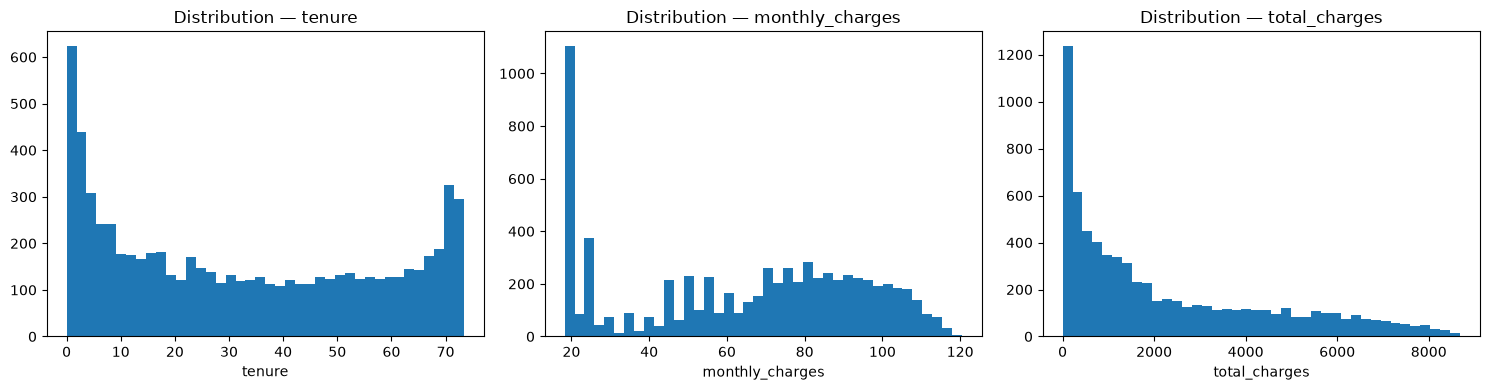

In [59]:
num_cols = ['tenure', 'monthly_charges', 'total_charges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, num_cols):
    ax.hist(pdf[c].dropna(), bins=40)
    ax.set_title(f'Distribution — {c}'); ax.set_xlabel(c)
plt.tight_layout(); plt.show()

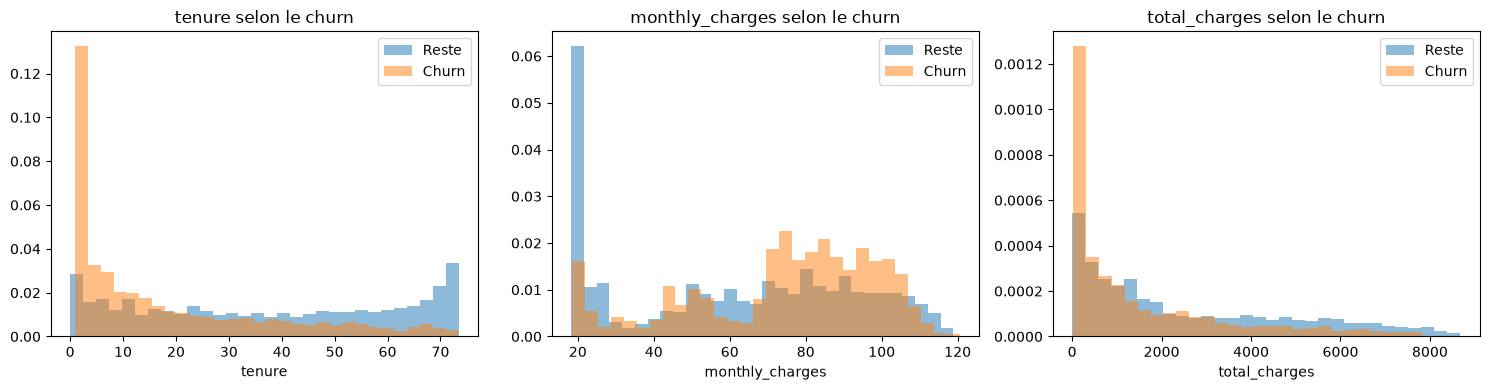

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, num_cols):
    for val, lab, col in [(0, 'Reste', 'tab:blue'), (1, 'Churn', 'tab:orange')]:
        ax.hist(pdf[pdf['churn'] == val][c].dropna(), bins=30, alpha=0.5,
                density=True, label=lab, color=col)
    ax.set_title(f'{c} selon le churn'); ax.set_xlabel(c); ax.legend()
plt.tight_layout(); plt.show()

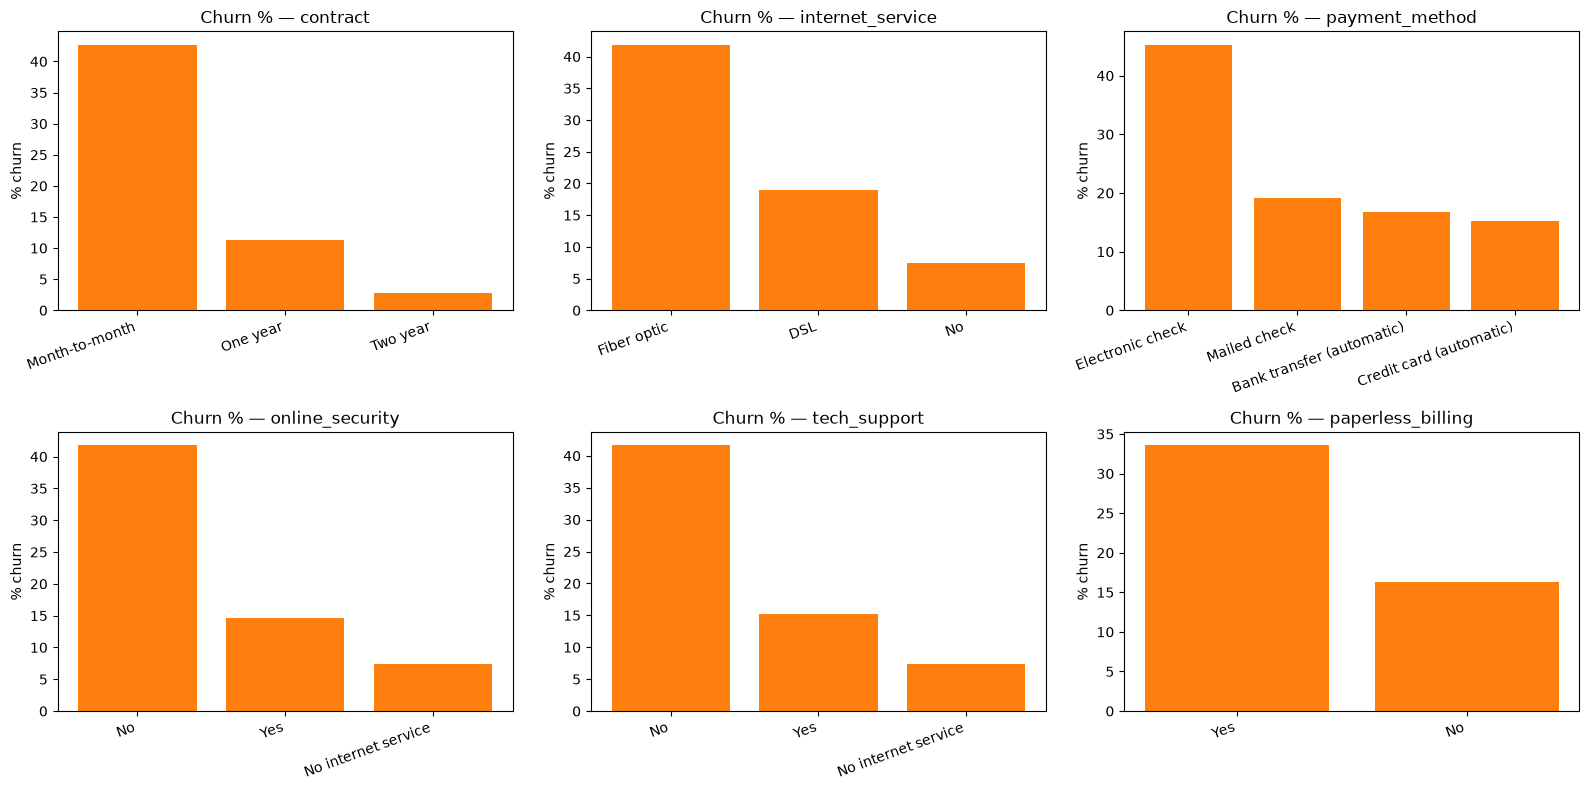

In [61]:
cat_plot = ['contract', 'internet_service', 'payment_method',
            'online_security', 'tech_support', 'paperless_billing']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), cat_plot):
    r = pdf.groupby(c)['churn'].mean().mul(100).sort_values(ascending=False)
    ax.bar(range(len(r)), r.values, color='tab:orange')
    ax.set_xticks(range(len(r))); ax.set_xticklabels(r.index, rotation=20, ha='right')
    ax.set_title(f'Churn % — {c}'); ax.set_ylabel('% churn')
plt.tight_layout(); plt.show()

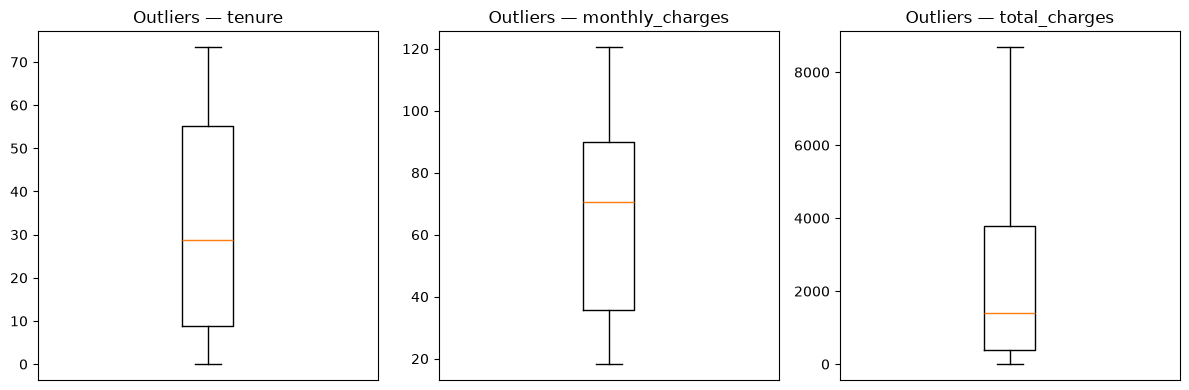

In [68]:
# Boxplots : visualisation des valeurs aberrantes sur les 3 numériques
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, c in zip(axes, num_cols):
    ax.boxplot(pdf[c].dropna())
    ax.set_title(f'Outliers — {c}')
    ax.set_xticks([])
plt.tight_layout(); plt.show()

### Boxplots — valeurs aberrantes

Les trois boxplots confirment les quantiles de la §5 : **aucune valeur aberrante à traiter**.

- `tenure` : boîte étalée 9–55 mois, moustaches couvrant 0–73, pas de points hors limites.
- `monthly_charges` : 34–90, médiane ~70, plage métier plausible (18–121 €).
- `total_charges` : forte asymétrie (médiane ~1 380, Q3 ~3 767), longue moustache haute — c'est
  une **distribution naturellement étalée**, pas des outliers à supprimer.

➡️ **Décision** : pas de capping ni de winsorisation. Les valeurs extrêmes sont des clients réels
(anciens / gros consommateurs), porteurs de signal — les retirer appauvrirait le modèle.

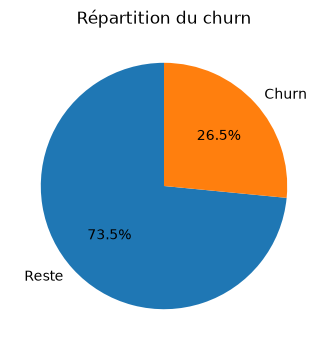

In [62]:
counts = pdf['churn'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(counts, labels=['Reste', 'Churn'], autopct='%1.1f%%',
       colors=['tab:blue', 'tab:orange'], startangle=90)
ax.set_title('Répartition du churn'); plt.show()

### Lecture des visualisations

**Variables numériques (distributions globales + selon le churn)**
- `tenure` : distribution **bimodale** (beaucoup de clients très récents ET beaucoup de très
  anciens). Superposée au churn, les départs s'écrasent sur **0–10 mois** : passé ce cap, le
  client se stabilise. **Métier** : la fenêtre de risque est l'onboarding, les premiers mois.
- `monthly_charges` : **bimodale** aussi — un pic à ~20 € (forfaits basiques, peu de churn) et une
  masse à 70–110 € (offres complètes, fibre). Les churners se concentrent sur la tranche haute
  **70–110 €**. **Métier** : facture élevée = client qui compare et part.
- `total_charges` : fortement **asymétrique à droite** (médiane ~1 380, longue traîne jusqu'à
  8 685). C'est mécaniquement `tenure × monthly` → variable redondante (traitée en §8).

**Variables catégorielles (barres de taux de churn — escalier = pouvoir prédictif)**
- `contract` : escalier le plus marqué — month-to-month **~43 %** → one year **~11 %** → two year
  **~3 %**. C'est le séparateur n°1 : l'engagement protège.
- `payment_method` : electronic check **~45 %** se détache nettement des 3 paiements automatiques
  (15–19 %). Le paiement non automatique = client moins ancré.
- `internet_service` : fiber optic **~42 %** >> DSL **~19 %** >> no **~7 %**. La fibre, chère et
  concurrentielle, fait fuir.
- `online_security` et `tech_support` : même forme — « No » **~42 %** vs « Yes » **~15 %** vs
  « No internet service » **~7 %**. Un client accompagné/sécurisé reste.
- `paperless_billing` : effet plus modéré — yes **~34 %** vs no **~16 %**, proxy d'un profil
  digital plus volatil.

**Cible** : ~26,5 % de churn (camembert) → déséquilibre confirmé visuellement, ce qui justifie
les métriques AUC-ROC / AUC-PR / F1 plutôt que l'accuracy.

**Note de lecture sur les 3 modalités de service.** La barre « No internet service » à ~7 % qui
revient sur `online_security`, `tech_support` (et toutes les options Internet) n'est pas un signal
propre : c'est le même sous-groupe « no internet » qui se répercute partout. C'est précisément la
redondance que l'analyse de multicolinéarité (§8) va quantifier et trancher.

## 8. Corrélations & multicolinéarité

On quantifie maintenant ce que les graphes suggèrent :
- Numériques (+ `senior_citizen`, binaire) ↔ Pearson.
- Catégorielles ↔ **V de Cramér** (0 = indépendance, 1 = lien parfait).

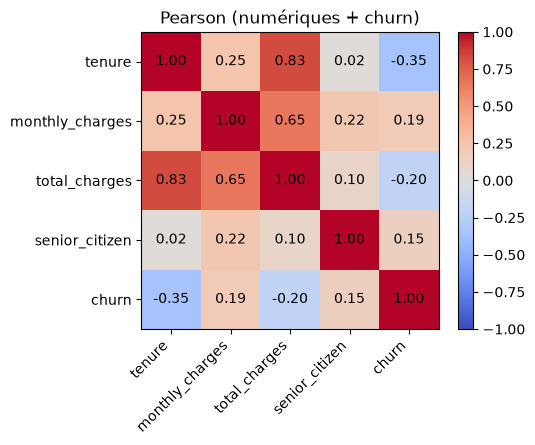

In [64]:
import numpy as np
num = ['tenure', 'monthly_charges', 'total_charges', 'senior_citizen', 'churn']
corr = pdf[num].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im); ax.set_title('Pearson (numériques + churn)')
plt.tight_layout(); plt.show()

### Pearson — décisions sur les numériques

- **Avec la cible** : `tenure` **−0,35** (protecteur, le plus fort), `monthly_charges` **+0,19**,
  `total_charges` −0,20, `senior_citizen` +0,15 (binaire : seniors churnent plus).
- **Entre features** : `tenure` ↔ `total_charges` = **0,83** (colinéarité mécanique :
  total ≈ tenure × monthly), `monthly_charges` ↔ `total_charges` = 0,65.

➡️ **Décision** : on retire `total_charges` (redondant) et on garde `tenure` + `monthly_charges`.
Son information utile est récupérée via la dérivée `avg_monthly_spend` (= total / tenure).

In [66]:
from itertools import combinations

def cramers_v(a, b):
    ct = pd.crosstab(a, b); n = ct.values.sum()
    exp = np.outer(ct.sum(axis=1), ct.sum(axis=0)) / n
    chi2 = ((ct.values - exp) ** 2 / exp).sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / max(1, min(r, k) - 1))

cat = ['partner', 'dependents', 'gender', 'internet_service', 'online_security',
       'tech_support', 'contract', 'paperless_billing', 'payment_method']

print('--- V de Cramér avec churn ---')
for c in sorted(cat, key=lambda c: -cramers_v(pdf[c], pdf['churn'])):
    print(f'{c:>18} : {cramers_v(pdf[c], pdf["churn"]):.3f}')

--- V de Cramér avec churn ---
          contract : 0.410
   online_security : 0.347
      tech_support : 0.343
  internet_service : 0.322
    payment_method : 0.303
 paperless_billing : 0.192
        dependents : 0.164
           partner : 0.150
            gender : 0.009


In [67]:
cat_full = ['partner', 'dependents', 'gender', 'phone_service', 'multiple_lines',
            'internet_service', 'online_security', 'online_backup', 'device_protection',
            'tech_support', 'streaming_tv', 'streaming_movies', 'contract',
            'paperless_billing', 'payment_method']

# il faut les colonnes dans pdf -> on recharge un échantillon large si besoin
pdf_full = (base.dropDuplicates(['base_id']).select(*cat_full, 'churn').toPandas())

print('--- Paires catégorielles V > 0.5 ---')
for v, a, b in sorted(((cramers_v(pdf_full[a], pdf_full[b]), a, b)
                       for a, b in combinations(cat_full, 2)), reverse=True):
    if v > 0.5:
        print(f'{a:>18} <-> {b:<18} : {v:.3f}')

--- Paires catégorielles V > 0.5 ---


     phone_service <-> multiple_lines     : 1.000
      streaming_tv <-> streaming_movies   : 0.771
 device_protection <-> streaming_movies   : 0.736
 device_protection <-> streaming_tv       : 0.734
   online_security <-> tech_support       : 0.733
 device_protection <-> tech_support       : 0.726
  internet_service <-> online_security    : 0.724
  internet_service <-> tech_support       : 0.723
     online_backup <-> tech_support       : 0.720
     online_backup <-> device_protection  : 0.719
   online_security <-> online_backup      : 0.718
   online_security <-> device_protection  : 0.717
  internet_service <-> streaming_tv       : 0.717
      tech_support <-> streaming_movies   : 0.716
      tech_support <-> streaming_tv       : 0.716
  internet_service <-> streaming_movies   : 0.716
     online_backup <-> streaming_tv       : 0.715
     online_backup <-> streaming_movies   : 0.714
   online_security <-> streaming_movies   : 0.708
   online_security <-> streaming_tv       : 0.708


### V de Cramér — décisions catégorielles

**Lien avec la cible** : `contract` 0,410 > `online_security` 0,347 > `tech_support` 0,343 >
`internet_service` 0,322 > `payment_method` 0,303 > … `multiple_lines` 0,040, `phone_service`
0,012, `gender` 0,009.
→ `gender`, `phone_service`, `multiple_lines` n'apportent rien (V < 0,05) : **écartées**.

**Multicolinéarité** :
- `phone_service` ↔ `multiple_lines` = **1,000** → redondance parfaite, une seule suffit.
- Les 6 services Internet + `internet_service` sont corrélés **0,70–0,77** entre eux (modalité
  commune « No internet service ») → quasi-équivalents.

➡️ **Traitement** : on résume les 6 services optionnels par `num_services`, on conserve à part
`online_security` et `tech_support` (signal le plus fort), `internet_service` reste le pivot.
Les autres services bruts sont écartés.

## 9. Synthèse — features définitives & feuille de route modélisation

### Décisions de sélection (issues des §6, §7, §8)

| Type | Features retenues | Justification |
|---|---|---|
| Numériques | `tenure`, `monthly_charges` | plus fortes corrélations à la cible ; non redondantes |
| Binaires | `senior_citizen` (rebinarisé), `partner`, `dependents` | prédicteurs démographiques nets |
| Catégorielles | `contract`, `payment_method`, `internet_service`, `online_security`, `tech_support`, `paperless_billing` | V de Cramér les plus élevés (0,19–0,41) |
| Dérivées (à construire au Gold) | `avg_monthly_spend`, `tenure_bucket`, `num_services` | remplacent `total_charges` et résument les services |

### Variables écartées et pourquoi

| Variable | Raison |
|---|---|
| `total_charges` | colinéarité 0,83 avec `tenure` (mécanique) → remplacée par `avg_monthly_spend` |
| `gender`, `phone_service`, `multiple_lines` | V de Cramér < 0,05 : aucun pouvoir prédictif |
| `online_backup`, `device_protection`, `streaming_tv`, `streaming_movies` | redondantes (V 0,70–0,77) → absorbées par `num_services` |

### Faits structurants à transmettre au modèle
1. **Anti-leakage** : split **par `base_id`** (= `customer_id` sans suffixe `-rNN`), jamais
   `randomSplit` aléatoire. → `base_id` doit être propagé jusqu'à `gold/churn_features`.
2. **Déséquilibre** 26,5 % churn → métriques **AUC-ROC / AUC-PR / F1**, pas l'accuracy.
   Baseline à battre = classe majoritaire (accuracy 73,5 %, AUC 0,5).
3. **Nettoyage Gold** : re-binariser `senior_citizen` (`round`).
4. **Profil du client à risque** : nouveau (faible tenure), en contrat mensuel, paiement
   electronic check, offre fibre, sans support technique, plutôt senior, sans foyer.
   → leviers de rétention : engagement contractuel, paiement automatique, onboarding, support proactif.

### Prochaine étape
**Feature engineering** : lecture de `silver/churn_clean` → construction des features ci-dessus
(+ `base_id`, `senior_citizen` rebinarisé, les 3 dérivées) → écriture dans `gold/churn_features`.

In [69]:
g = spark.read.parquet(config.s3_path('gold_feat'))
print(g.columns); print('lignes :', g.count())
g.select('base_id','tenure_bucket','avg_monthly_spend','num_services').show(5)

['base_id', 'customer_id', 'tenure', 'monthly_charges', 'senior_citizen', 'partner', 'dependents', 'contract', 'payment_method', 'internet_service', 'online_security', 'tech_support', 'paperless_billing', 'tenure_bucket', 'avg_monthly_spend', 'num_services', 'churn']


lignes : 704300


+----------+-------------+-----------------+------------+
|   base_id|tenure_bucket|avg_monthly_spend|num_services|
+----------+-------------+-----------------+------------+
|7218-HKQFK|         0-1y|82.77139517916206|           3|
|8593-WHYHV|         0-1y|89.69438636730935|           1|
|5207-PLSTK|         0-1y|48.99732291251777|           1|
|2485-ITVKB|         0-1y|33.76670937884659|           1|
|4514-GFCFI|         1-2y|84.90457992836686|           1|
+----------+-------------+-----------------+------------+
only showing top 5 rows
